# Solutions for Assignment 5: Exploring Yelp Reviews in Philadelphia

In this assignment, we'll explore restaurant review data available through the [Yelp Dataset Challenge](https://www.yelp.com/dataset). The dataset includes Yelp data for user reviews and business information for many metropolitan areas. I've already downloaded this dataset (8 GB total!) and extracted out the data files for reviews and restaurants in Philadelphia. Please download it from **([HERE](restaurants_philly.json.gz)**). 

In this assignment we are going to analyze correlations between restaurant reviews and census data
We'll explore the relationship between restaurant reviews and the income levels of the restaurant's surrounding area.

**Background readings**
- [Does sentiment analysis work?](http://varianceexplained.org/r/yelp-sentiment/)
- [The Geography of Taste: Using Yelp to Study Urban Culture](https://www.mdpi.com/2220-9964/7/9/376/pdf/1)

**Set up**

In [1]:
#!pip install cenpy
#!pip install pygris
import geopandas as gpd
import holoviews as hv
import hvplot.pandas
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from shapely.geometry import Point
import cenpy as c
import pandas as pd
import pygris

c:\Users\Lingx\anaconda3\envs\geospatial\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


## 1. Correlating restaurant ratings and income levels

In this part, we'll use the census API to download household income data and explore how it correlates with restaurant review data.

### 1.1 Query the Census API

Use the `cenpy` package to download **median household income in the past 12 months** by census tract from the 2021 ACS 5-year data set for your county of interest.

You have two options to find the correct variable names:
- Search through: [https://api.census.gov/data/2021/acs/acs5/variables.html](https://api.census.gov/data/2021/acs/acs5/variables.html)
- Initialize an API connection and use the `.varslike()` function to search for the proper keywords 

At the end of this step, you should have a pandas DataFrame holding the income data for all census tracts within the county being analyzed. Feel free to rename your variable from the ACS so it has a more meaningful name!

::: {.callout-caution}
Some census tracts won't have any value because there are not enough households in that tract. The census will use a negative number as a default value for those tracts. You can safely remove those tracts from the analysis!
:::

In [2]:
from cenpy.remote import APIConnection

In [3]:
api = APIConnection("ACSDT5Y2021")

In [4]:
api.varslike("median household income")


,label,concept,predicateType,group,limit,predicateOnly,hasGeoCollectionSupport,attributes,required


In [5]:
from cenpy.remote import APIConnection
import pandas as pd

income = api.query(
    cols=["NAME", "GEO_ID", "B19013_001E"],
    geo_unit="tract:*",
    geo_filter={"state": "42", "county": "101"}
)

income = income.rename(columns={"B19013_001E": "median_income"})
income["median_income"] = income["median_income"].astype(float)
income = income[income["median_income"] >= 0]

income.head()

,NAME,GEO_ID,median_income,state,county,tract
0,"Census Tract 1.01, Philadelphia County, Pennsy...",1400000US42101000101,104052.0,42,101,000101
1,"Census Tract 1.02, Philadelphia County, Pennsy...",1400000US42101000102,91944.0,42,101,000102
2,"Census Tract 2, Philadelphia County, Pennsylvania",1400000US42101000200,91067.0,42,101,000200
3,"Census Tract 3, Philadelphia County, Pennsylvania",1400000US42101000300,86782.0,42,101,000300
4,"Census Tract 4.01, Philadelphia County, Pennsy...",1400000US42101000401,67188.0,42,101,000401


### 1.2 Download census tracts from the Census and merge the data from part 1.1

- Download census tracts for the desired geography using the `pygris` package
- Merge the downloaded census tracts with the household income DataFrame

In [6]:
tracts = pygris.tracts(
    state="PA", 
    county="Philadelphia", 
    year=2021, 
    cache=True
)

Using FIPS code '42' for input 'PA'
Using FIPS code '101' for input 'Philadelphia'


In [7]:
tracts.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
68,42,101,039100,42101039100,391,Census Tract 391,G5020,S,1119799,133239,+39.9332720,-075.2132103,"POLYGON ((-75.22235 39.93105, -75.22129 39.931..."
69,42,101,980902,42101980902,9809.02,Census Tract 9809.02,G5020,S,132548,50536,+39.9346276,-075.2046321,"POLYGON ((-75.20684 39.93409, -75.20655 39.934..."
70,42,101,980904,42101980904,9809.04,Census Tract 9809.04,G5020,S,1570844,158459,+39.9247300,-075.2036710,"POLYGON ((-75.21243 39.92523, -75.2113 39.9284..."
71,42,101,980903,42101980903,9809.03,Census Tract 9809.03,G5020,S,171154,0,+39.9347932,-075.2009884,"POLYGON ((-75.20422 39.93285, -75.20305 39.934..."
72,42,101,980906,42101980906,9809.06,Census Tract 9809.06,G5020,S,2945390,383112,+39.9095823,-075.1984052,"POLYGON ((-75.21612 39.90964, -75.21454 39.910..."


In [8]:
income["TRACTCE"] = income["GEO_ID"].str[-6:]


In [9]:
tracts_income = tracts.merge(
    income[["TRACTCE", "median_income"]],
    on="TRACTCE",
    how="left"
)


In [10]:
tracts_income

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,median_income
0,42,101,039100,42101039100,391,Census Tract 391,G5020,S,1119799,133239,+39.9332720,-075.2132103,"POLYGON ((-75.22235 39.93105, -75.22129 39.931...",30077.0
1,42,101,980902,42101980902,9809.02,Census Tract 9809.02,G5020,S,132548,50536,+39.9346276,-075.2046321,"POLYGON ((-75.20684 39.93409, -75.20655 39.934...",NaN
2,42,101,980904,42101980904,9809.04,Census Tract 9809.04,G5020,S,1570844,158459,+39.9247300,-075.2036710,"POLYGON ((-75.21243 39.92523, -75.2113 39.9284...",NaN
3,42,101,980903,42101980903,9809.03,Census Tract 9809.03,G5020,S,171154,0,+39.9347932,-075.2009884,"POLYGON ((-75.20422 39.93285, -75.20305 39.934...",NaN
4,42,101,980906,42101980906,9809.06,Census Tract 9809.06,G5020,S,2945390,383112,+39.9095823,-075.1984052,"POLYGON ((-75.21612 39.90964, -75.21454 39.910...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,42,101,013602,42101013602,136.02,Census Tract 136.02,G5020,S,246812,0,+39.9716057,-075.1800748,"POLYGON ((-75.18637 39.97354, -75.18604 39.973...",103426.0
404,42,101,034502,42101034502,345.02,Census Tract 345.02,G5020,S,1021734,0,+40.0814101,-075.0384569,"POLYGON ((-75.04729 40.08293, -75.04652 40.083...",49636.0
405,42,101,000902,42101000902,9.02,Census Tract 9.02,G5020,S,155167,0,+39.9471596,-075.1566389,"POLYGON ((-75.16017 39.94686, -75.16014 39.947...",67014.0
406,42,101,001201,42101001201,12.01,Census Tract 12.01,G5020,S,327555,30728,+39.9470373,-075.1799169,"POLYGON ((-75.18714 39.94722, -75.18563 39.948...",106871.0


### 1.3 Load the restaurants data

The Yelp dataset includes data for 7,350 restaurants across the city. Load the data from the `data/` folder and use the `latitude` and `longitude` columns to create a GeoDataFrame after loading the JSON data. Be sure to set the right CRS on when initializing the GeoDataFrame!

**Notes**

The JSON data is in a "records" format. To load it, you'll need to pass the following keywords: 

- `orient='records'`
- `lines=True`

In [11]:
restaurants = pd.read_json(
    "data/restaurants_philly.json",
    orient="records",
    lines=True
)

geometry = [
    Point(xy) for xy in zip(restaurants["longitude"], restaurants["latitude"])
]

gdf_restaurants = gpd.GeoDataFrame(
    restaurants,
    geometry=gpd.points_from_xy(
        restaurants['longitude'],
        restaurants['latitude']
    ),
    crs="EPSG:4326"
)

In [12]:
gdf_restaurants

,business_id,latitude,longitude,name,review_count,stars,categories,geometry
0,MTSW4McQd7CbVtyjqoe9mw,39.955505,-75.155564,St Honore Pastries,80,4.0,"Restaurants, Food, Bubble Tea, Coffee & Tea, B...",POINT (-75.15556 39.95551)
1,MUTTqe8uqyMdBl186RmNeA,39.953949,-75.143226,Tuna Bar,245,4.0,"Sushi Bars, Restaurants, Japanese",POINT (-75.14323 39.95395)
2,ROeacJQwBeh05Rqg7F6TCg,39.943223,-75.162568,BAP,205,4.5,"Korean, Restaurants",POINT (-75.16257 39.94322)
3,QdN72BWoyFypdGJhhI5r7g,39.939825,-75.157447,Bar One,65,4.0,"Cocktail Bars, Bars, Italian, Nightlife, Resta...",POINT (-75.15745 39.93982)
4,Mjboz24M9NlBeiOJKLEd_Q,40.022466,-75.218314,DeSandro on Main,41,3.0,"Pizza, Restaurants, Salad, Soup",POINT (-75.21831 40.02247)
...,...,...,...,...,...,...,...,...
7345,VZbkSeZtFynEascotq7ExA,39.953391,-75.196765,Ali Baba Magic Food,8,4.0,"Restaurants, Food Stands",POINT (-75.19677 39.95339)
7346,gPr1io7ks0Eo3FDsnDTYfg,40.060414,-75.191084,Tata Cafe,21,4.0,"Sandwiches, Restaurants, Italian",POINT (-75.19108 40.06041)
7347,wVxXRFf10zTTAs11nr4xeA,40.032483,-75.214430,PrimoHoagies,55,3.0,"Restaurants, Specialty Food, Food, Sandwiches,...",POINT (-75.21443 40.03248)
7348,8n93L-ilMAsvwUatarykSg,39.951018,-75.198240,Kitchen Gia,22,3.0,"Coffee & Tea, Food, Sandwiches, American (Trad...",POINT (-75.19824 39.95102)


### 1.4 Add tract info and income data for each restaurant

Do a spatial join to identify which census tract each restaurant is within. Make sure each dataframe has the same CRS!

At the end of this step, you should have a new dataframe with column2 identifying the tract number and the median income for each restaurant.

In [13]:
tracts_income = tracts_income.to_crs(epsg=4326)

In [14]:
restaurants_income = gpd.sjoin(
    gdf_restaurants,
    tracts_income[["TRACTCE", "geometry","median_income"]],
    how="left",
    predicate="within"
)


In [15]:
restaurants_income

,business_id,latitude,longitude,name,review_count,stars,categories,geometry,index_right,TRACTCE,median_income
0,MTSW4McQd7CbVtyjqoe9mw,39.955505,-75.155564,St Honore Pastries,80,4.0,"Restaurants, Food, Bubble Tea, Coffee & Tea, B...",POINT (-75.15556 39.95551),113.0,000200,91067.0
1,MUTTqe8uqyMdBl186RmNeA,39.953949,-75.143226,Tuna Bar,245,4.0,"Sushi Bars, Restaurants, Japanese",POINT (-75.14323 39.95395),311.0,000102,91944.0
2,ROeacJQwBeh05Rqg7F6TCg,39.943223,-75.162568,BAP,205,4.5,"Korean, Restaurants",POINT (-75.16257 39.94322),67.0,001500,93203.0
3,QdN72BWoyFypdGJhhI5r7g,39.939825,-75.157447,Bar One,65,4.0,"Cocktail Bars, Bars, Italian, Nightlife, Resta...",POINT (-75.15745 39.93982),29.0,001800,99125.0
4,Mjboz24M9NlBeiOJKLEd_Q,40.022466,-75.218314,DeSandro on Main,41,3.0,"Pizza, Restaurants, Salad, Soup",POINT (-75.21831 40.02247),288.0,021000,79264.0
...,...,...,...,...,...,...,...,...,...,...,...
7345,VZbkSeZtFynEascotq7ExA,39.953391,-75.196765,Ali Baba Magic Food,8,4.0,"Restaurants, Food Stands",POINT (-75.19677 39.95339),255.0,008801,36250.0
7346,gPr1io7ks0Eo3FDsnDTYfg,40.060414,-75.191084,Tata Cafe,21,4.0,"Sandwiches, Restaurants, Italian",POINT (-75.19108 40.06041),243.0,025600,92404.0
7347,wVxXRFf10zTTAs11nr4xeA,40.032483,-75.214430,PrimoHoagies,55,3.0,"Restaurants, Specialty Food, Food, Sandwiches,...",POINT (-75.21443 40.03248),204.0,021300,79464.0
7348,8n93L-ilMAsvwUatarykSg,39.951018,-75.198240,Kitchen Gia,22,3.0,"Coffee & Tea, Food, Sandwiches, American (Trad...",POINT (-75.19824 39.95102),315.0,036902,27821.0


### 1.5 Make a plot of median household income vs. Yelp stars

Our dataset has the number of stars for each restaurant, rounded to the nearest 0.5 star. In this step, create a line plot that shows the average income value for each stars category (e.g., all restaurants with 1 star, 1.5 stars, 2 stars, etc.)

While their are multiple ways to do this, the [seaborn.lineplot()](https://seaborn.pydata.org/generated/seaborn.lineplot.html) is a great option. This can show the average value in each category as well as 95% uncertainty intervals. Use this function to plot the stars ("x") vs. average income ("y") for all of our restaurants, using the dataframe from last step. Be sure to format your figure to make it look nice!

**Question:** Is there a correlation between a restaurant's ratings and the income levels of its surrounding neighborhood?

C:\Users\Lingx\AppData\Local\Temp\ipykernel_22224\1502200285.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  ax = sns.lineplot(


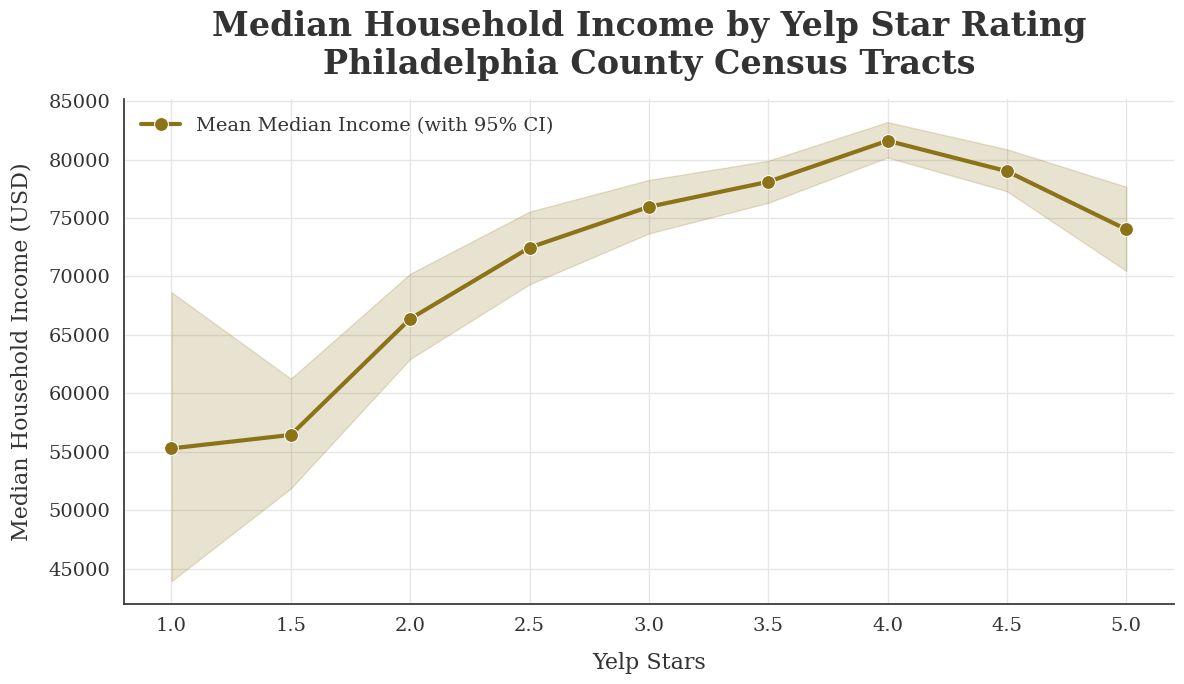

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


plt.style.use("default")
sns.set_theme(style="whitegrid")

plt.rcParams["font.family"] = "serif"            
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["text.color"] = "#333333"
plt.rcParams["axes.labelcolor"] = "#333333"
plt.rcParams["xtick.color"] = "#333333"
plt.rcParams["ytick.color"] = "#333333"

#PLOT
plt.figure(figsize=(12, 7))

ax = sns.lineplot(
    data=restaurants_income,
    x="stars",
    y="median_income",
    ci=95,  
    marker="o",
    markersize=10,
    linewidth=3,
    color="#8d7318", 
    label="Mean Median Income (with 95% CI)"
)
plt.title(
    "Median Household Income by Yelp Star Rating\nPhiladelphia County Census Tracts",
    fontsize=24,
    weight="bold",
    pad=18
)

plt.xlabel("Yelp Stars", fontsize=16, labelpad=12)
plt.ylabel("Median Household Income (USD)", fontsize=16, labelpad=12)

plt.xticks(sorted(restaurants_income["stars"].unique()), fontsize=14)
plt.yticks(fontsize=14)

sns.despine()

plt.grid(which="major", color="#e6e6e6", linewidth=1)

plt.legend(frameon=False, fontsize=14)

plt.tight_layout()
plt.show()


Based on the plot, restaurants with higher Yelp ratings tend to be located in wealthier neighborhoods. As the stars go up from 1 to around 4, the median household income of the surrounding census tracts rises  steadily, which suggests a clear positive relationship between rating and local income levels. There’s a small dip at the very high end (4.5–5 stars), but overall the pattern is strong: better-rated restaurants are usually found in more affluent parts of the city. This could reflect things like higher customer expectations in richer areas, more competition, or just the types of restaurants that tend to open and succeed there.